In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_excel('HousePricePrediction_2features.xlsx')
display(df.head())

,Id,SIZE,PRICE
0,0,8450,208500.0
1,1,9600,181500.0
2,2,11250,223500.0
3,3,9550,140000.0
4,4,14260,250000.0


In [ ]:
print(df.isnull().sum())

Id          0
SIZE        0
PRICE    1459
dtype: int64


In [ ]:
df.dropna(subset=['PRICE'], inplace=True)
print(f"Remaining rows after dropping missing values: {df.shape[0]}")
print(f"Remaining columns: {df.shape[1]}")

Remaining rows after dropping missing values: 1460
Remaining columns: 3


In [ ]:
df = pd.read_excel('/content/drive/MyDrive/HousePricePrediction_2features.xlsx')
df.dropna(subset=['PRICE'], inplace=True)
X = df[['SIZE']]
y = df['PRICE']
display(df.head())
print(df.isnull().sum())

,Id,SIZE,YEARBUILT,PRICE
0,0,8450,2003,208500.0
1,1,9600,1976,181500.0
2,2,11250,2001,223500.0
3,3,9550,1915,140000.0
4,4,14260,2000,250000.0


Id           0
SIZE         0
YEARBUILT    0
PRICE        0
dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split, TimeSeriesSplit, KFold

# 1. Random Split
X_train_rand, X_temp, y_train_rand, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val_rand, X_test_rand, y_val_rand, y_test_rand = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 2. Time-Series Split (using SIZE as a proxy for time/order)
df_sorted = df.sort_values(by='SIZE')
X_sorted = df_sorted[['SIZE']]
y_sorted = df_sorted['PRICE']

tscv = TimeSeriesSplit(n_splits=5)
for fold, (train_index, test_index) in enumerate(tscv.split(X_sorted)):
    if fold == tscv.n_splits - 1: # Last fold for testing
        X_test_time, y_test_time = X_sorted.iloc[test_index], y_sorted.iloc[test_index]
    elif fold == tscv.n_splits - 2: # Second to last fold for validation
        X_val_time, y_val_time = X_sorted.iloc[test_index], y_sorted.iloc[test_index]
    else: # Remaining folds for training
        if 'X_train_time' not in locals():
            X_train_time, y_train_time = X_sorted.iloc[train_index], y_sorted.iloc[train_index]
        else:
            X_train_time = pd.concat([X_train_time, X_sorted.iloc[train_index]])
            y_train_time = pd.concat([y_train_time, y_sorted.iloc[train_index]])

# 3. K-Fold Cross-Validation (using fold 0 for validation, fold 1 for test, and remaining for train)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for fold, (train_index, test_index) in enumerate(kf.split(X, y)):
    if fold == 0: # First fold for validation
        X_val_kf, y_val_kf = X.iloc[test_index], y.iloc[test_index]
    elif fold == 1: # Second fold for testing
        X_test_kf, y_test_kf = X.iloc[test_index], y.iloc[test_index]
    else: # Remaining folds for training
        if 'X_train_kf' not in locals():
            X_train_kf, y_train_kf = X.iloc[train_index], y.iloc[train_index]
        else:
            X_train_kf = pd.concat([X_train_kf, X.iloc[train_index]])
            y_train_kf = pd.concat([y_train_kf, y.iloc[train_index]])

print("Random Split shapes:")
print(f"X_train_rand: {X_train_rand.shape}, y_train_rand: {y_train_rand.shape}")
print(f"X_val_rand: {X_val_rand.shape}, y_val_rand: {y_val_rand.shape}")
print(f"X_test_rand: {X_test_rand.shape}, y_test_rand: {y_test_rand.shape}")

print("\nTime-Series Split shapes:")
print(f"X_train_time: {X_train_time.shape}, y_train_time: {y_train_time.shape}")
print(f"X_val_time: {X_val_time.shape}, y_val_time: {y_val_time.shape}")
print(f"X_test_time: {X_test_time.shape}, y_test_time: {y_test_time.shape}")

print("\nK-Fold Split shapes:")
print(f"X_train_kf: {X_train_kf.shape}, y_train_kf: {y_train_kf.shape}")
print(f"X_val_kf: {X_val_kf.shape}, y_val_kf: {y_val_kf.shape}")
print(f"X_test_kf: {X_test_kf.shape}, y_test_kf: {y_test_kf.shape}")

Random Split shapes:
X_train_rand: (876, 1), y_train_rand: (876,)
X_val_rand: (292, 1), y_val_rand: (292,)
X_test_rand: (292, 1), y_test_rand: (292,)

Time-Series Split shapes:
X_train_time: (2485, 1), y_train_time: (2485,)
X_val_time: (243, 1), y_val_time: (243,)
X_test_time: (243, 1), y_test_time: (243,)

K-Fold Split shapes:
X_train_kf: (4672, 1), y_train_kf: (4672,)
X_val_kf: (292, 1), y_val_kf: (292,)
X_test_kf: (292, 1), y_test_kf: (292,)


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge

# Initialize models
lr = LinearRegression()
ridge = Ridge()

# Train on Random Split
lr_rand = lr.fit(X_train_rand, y_train_rand)
ridge_rand = ridge.fit(X_train_rand, y_train_rand)
print("Models trained on Random Split.")

# Train on Time-Series Split
lr_time = lr.fit(X_train_time, y_train_time)
ridge_time = ridge.fit(X_train_time, y_train_time)
print("Models trained on Time-Series Split.")

# Train on K-Fold Split
lr_kf = lr.fit(X_train_kf, y_train_kf)
ridge_kf = ridge.fit(X_train_kf, y_train_kf)
print("Models trained on K-Fold Split.")

Models trained on Random Split.
Models trained on Time-Series Split.
Models trained on K-Fold Split.


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results = {}

In [ ]:
# Evaluate on Random Split
y_pred_val_rand_lr = lr_rand.predict(X_val_rand)
y_pred_test_rand_lr = lr_rand.predict(X_test_rand)
y_pred_val_rand_ridge = ridge_rand.predict(X_val_rand)
y_pred_test_rand_ridge = ridge_rand.predict(X_test_rand)

results['LinearRegression_Random_Validation'] = {
    'MSE': mean_squared_error(y_val_rand, y_pred_val_rand_lr),
    'RMSE': np.sqrt(mean_squared_error(y_val_rand, y_pred_val_rand_lr)),
    'MAE': mean_absolute_error(y_val_rand, y_pred_val_rand_lr),
    'R2': r2_score(y_val_rand, y_pred_val_rand_lr)
}
results['Ridge_Random_Validation'] = {
    'MSE': mean_squared_error(y_val_rand, y_pred_val_rand_ridge),
    'RMSE': np.sqrt(mean_squared_error(y_val_rand, y_pred_val_rand_ridge)),
    'MAE': mean_absolute_error(y_val_rand, y_pred_val_rand_ridge),
    'R2': r2_score(y_val_rand, y_pred_val_rand_ridge)
}
results['LinearRegression_Random_Test'] = {
    'MSE': mean_squared_error(y_test_rand, y_pred_test_rand_lr),
    'RMSE': np.sqrt(mean_squared_error(y_test_rand, y_pred_test_rand_lr)),
    'MAE': mean_absolute_error(y_test_rand, y_pred_test_rand_lr),
    'R2': r2_score(y_test_rand, y_pred_test_rand_lr)
}
results['Ridge_Random_Test'] = {
    'MSE': mean_squared_error(y_test_rand, y_pred_test_rand_ridge),
    'RMSE': np.sqrt(mean_squared_error(y_test_rand, y_pred_test_rand_ridge)),
    'MAE': mean_absolute_error(y_test_rand, y_pred_test_rand_ridge),
    'R2': r2_score(y_test_rand, y_pred_test_rand_ridge)
}

# Evaluate on Time-Series Split
y_pred_val_time_lr = lr_time.predict(X_val_time)
y_pred_test_time_lr = lr_time.predict(X_test_time)
y_pred_val_time_ridge = ridge_time.predict(X_val_time)
y_pred_test_time_ridge = ridge_time.predict(X_test_time)

results['LinearRegression_Time_Validation'] = {
    'MSE': mean_squared_error(y_val_time, y_pred_val_time_lr),
    'RMSE': np.sqrt(mean_squared_error(y_val_time, y_pred_val_time_lr)),
    'MAE': mean_absolute_error(y_val_time, y_pred_val_time_lr),
    'R2': r2_score(y_val_time, y_pred_val_time_lr)
}
results['Ridge_Time_Validation'] = {
    'MSE': mean_squared_error(y_val_time, y_pred_val_time_ridge),
    'RMSE': np.sqrt(mean_squared_error(y_val_time, y_pred_val_time_ridge)),
    'MAE': mean_absolute_error(y_val_time, y_pred_val_time_ridge),
    'R2': r2_score(y_val_time, y_pred_val_time_ridge)
}
results['LinearRegression_Time_Test'] = {
    'MSE': mean_squared_error(y_test_time, y_pred_test_time_lr),
    'RMSE': np.sqrt(mean_squared_error(y_test_time, y_pred_test_time_lr)),
    'MAE': mean_absolute_error(y_test_time, y_pred_test_time_lr),
    'R2': r2_score(y_test_time, y_pred_test_time_lr)
}
results['Ridge_Time_Test'] = {
    'MSE': mean_squared_error(y_test_time, y_pred_test_time_ridge),
    'RMSE': np.sqrt(mean_squared_error(y_test_time, y_pred_test_time_ridge)),
    'MAE': mean_absolute_error(y_test_time, y_pred_test_time_ridge),
    'R2': r2_score(y_test_time, y_pred_test_time_ridge)
}

# Evaluate on K-Fold Split
y_pred_val_kf_lr = lr_kf.predict(X_val_kf)
y_pred_test_kf_lr = lr_kf.predict(X_test_kf)
y_pred_val_kf_ridge = ridge_kf.predict(X_val_kf)
y_pred_test_kf_ridge = ridge_kf.predict(X_test_kf)

results['LinearRegression_KFold_Validation'] = {
    'MSE': mean_squared_error(y_val_kf, y_pred_val_kf_lr),
    'RMSE': np.sqrt(mean_squared_error(y_val_kf, y_pred_val_kf_lr)),
    'MAE': mean_absolute_error(y_val_kf, y_pred_val_kf_lr),
    'R2': r2_score(y_val_kf, y_pred_val_kf_lr)
}
results['Ridge_KFold_Validation'] = {
    'MSE': mean_squared_error(y_val_kf, y_pred_val_kf_ridge),
    'RMSE': np.sqrt(mean_squared_error(y_val_kf, y_pred_val_kf_ridge)),
    'MAE': mean_absolute_error(y_val_kf, y_pred_val_kf_ridge),
    'R2': r2_score(y_val_kf, y_pred_val_kf_ridge)
}
results['LinearRegression_KFold_Test'] = {
    'MSE': mean_squared_error(y_test_kf, y_pred_test_kf_lr),
    'RMSE': np.sqrt(mean_squared_error(y_test_kf, y_pred_test_kf_lr)),
    'MAE': mean_absolute_error(y_test_kf, y_pred_test_kf_lr),
    'R2': r2_score(y_test_kf, y_pred_test_kf_lr)
}
results['Ridge_KFold_Test'] = {
    'MSE': mean_squared_error(y_test_kf, y_pred_test_kf_ridge),
    'RMSE': np.sqrt(mean_squared_error(y_test_kf, y_pred_test_kf_ridge)),
    'MAE': mean_absolute_error(y_test_kf, y_pred_test_kf_ridge),
    'R2': r2_score(y_test_kf, y_pred_test_kf_ridge)
}

print(results)

{'LinearRegression_Random_Validation': {'MSE': 8757523962.383036, 'RMSE': np.float64(93581.64329815455), 'MAE': 61917.04934109138, 'R2': 0.07005342721799868}, 'Ridge_Random_Validation': {'MSE': 8757523962.384401, 'RMSE': np.float64(93581.64329816186), 'MAE': 61917.04934109515, 'R2': 0.07005342721785368}, 'LinearRegression_Random_Test': {'MSE': 4713521461.858592, 'RMSE': np.float64(68655.09057497916), 'MAE': 53017.87259723602, 'R2': 0.03620581009981838}, 'Ridge_Random_Test': {'MSE': 4713521461.858958, 'RMSE': np.float64(68655.09057498182), 'MAE': 53017.87259723868, 'R2': 0.03620581009974355}, 'LinearRegression_Time_Validation': {'MSE': 6311432457.809652, 'RMSE': np.float64(79444.52440420077), 'MAE': 60010.154704992485, 'R2': -0.08082175908819278}, 'Ridge_Time_Validation': {'MSE': 6311432457.809973, 'RMSE': np.float64(79444.52440420279), 'MAE': 60010.15470499282, 'R2': -0.08082175908824762}, 'LinearRegression_Time_Test': {'MSE': 15408486585.889996, 'RMSE': np.float64(124130.92517938468),

In [ ]:
results_df = pd.DataFrame.from_dict(results, orient='index')
results_df = results_df.reset_index().rename(columns={'index': 'Model_Split'})
results_melted = results_df.melt(id_vars='Model_Split', var_name='Metric', value_name='Score')
results_melted[['Model', 'Split_Set', 'Evaluation_Set']] = results_melted['Model_Split'].str.rsplit('_', n=2, expand=True)
display(results_melted.head())

,Model_Split,Metric,Score,Model,Split_Set,Evaluation_Set
0,LinearRegression_Random_Validation,MSE,8.757524e+09,LinearRegression,Random,Validation
1,Ridge_Random_Validation,MSE,8.757524e+09,Ridge,Random,Validation
2,LinearRegression_Random_Test,MSE,4.713521e+09,LinearRegression,Random,Test
3,Ridge_Random_Test,MSE,4.713521e+09,Ridge,Random,Test
4,LinearRegression_Time_Validation,MSE,6.311432e+09,LinearRegression,Time,Validation


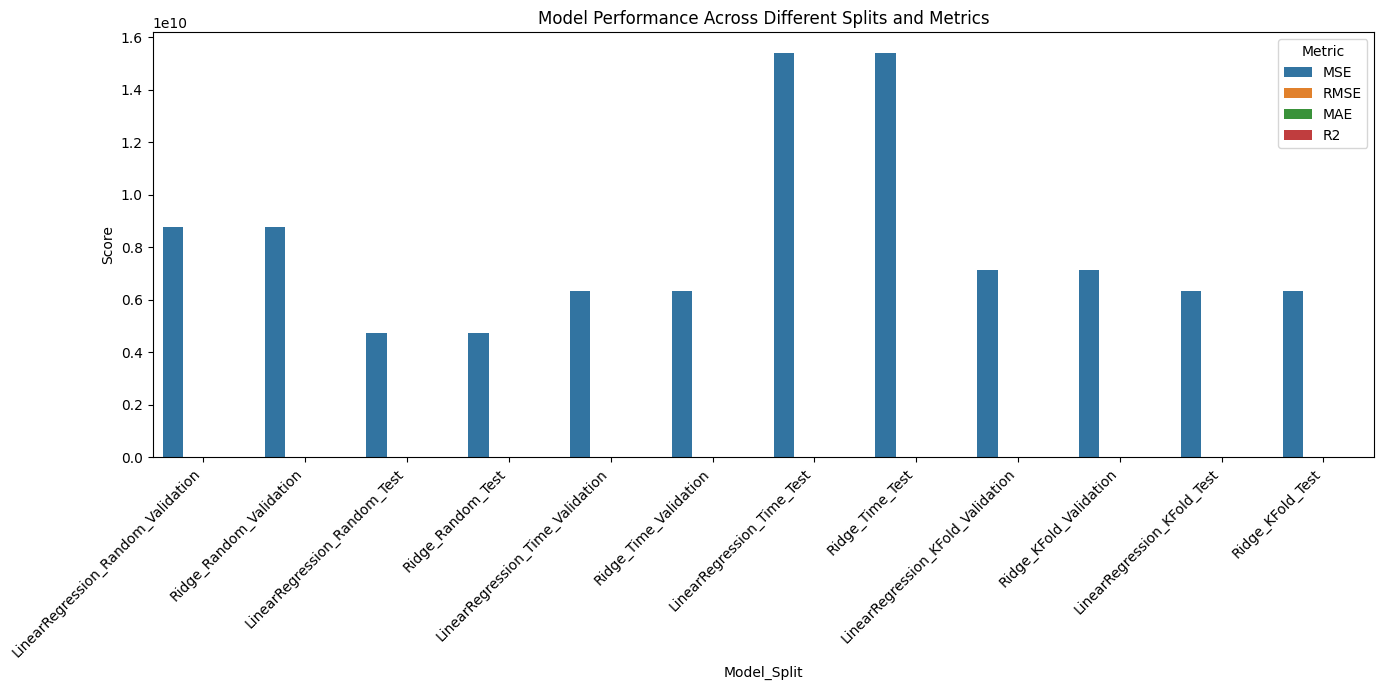

In [ ]:
plt.figure(figsize=(14, 7))
sns.barplot(x='Model_Split', y='Score', hue='Metric', data=results_melted)
plt.xticks(rotation=45, ha='right')
plt.title('Model Performance Across Different Splits and Metrics')
plt.tight_layout()
plt.show()

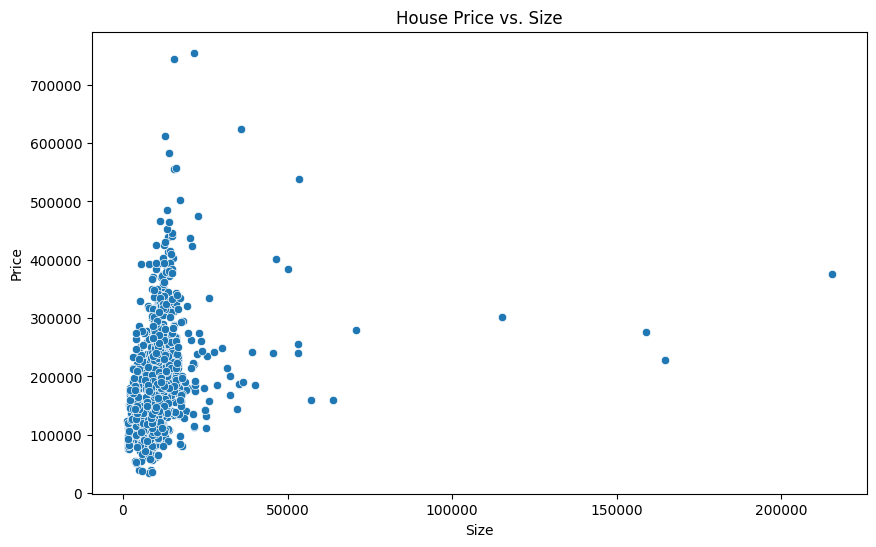

Correlation coefficient between SIZE and PRICE: 0.2638433538714056


In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='SIZE', y='PRICE', data=df)
plt.title('House Price vs. Size')
plt.xlabel('Size')
plt.ylabel('Price')
plt.show()

correlation = df['SIZE'].corr(df['PRICE'])
print(f"Correlation coefficient between SIZE and PRICE: {correlation}")